In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import matplotlib.ticker as ticker
#import matplotlib.gridspec as gridspec


In [2]:
topo_file = xr.open_dataset("/home/mbucek/Miocene_Files/share/miocene_topo_pollard_antscape_dolan_0.5x0.5.nc",decode_times=False)

ds = xr.open_dataset("/groups/NBURLS/MioceneHydroProject/mbucek_files/hist/iF_MMIOx1_C5_840_B22WNA_FM23CA_icesm1.3.01_ALL_concat.nc",decode_times=False)
ds

<xarray.Dataset>
Dimensions:        (time: 193, lev: 30, ilev: 31, slat: 191, nbnd: 2, lat: 192, lon: 288, slon: 288)
Coordinates:
  * lev            (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev           (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time           (time) float64 31.0 59.0 90.0 ... 5.84e+03 5.871e+03
  * lat            (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon            (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * slat           (slat) float64 -89.53 -88.59 -87.64 ... 87.64 88.59 89.53
  * slon           (slon) float64 -0.625 0.625 1.875 3.125 ... 355.6 356.9 358.1
Dimensions without coordinates: nbnd
Data variables: (12/216)
    hyam           (time, lev) float64 ...
    hybm           (time, lev) float64 ...
    P0             (time) float64 ...
    hyai           (time, ilev) float64 ...
    hybi           (time, ilev) float64 ...
    date           (time) int32 ...
    ...             ...
    pom_a1_SRF     (time, lat, lon) float32 ...
    so4_a1_SRF     (time, lat, lon) float32 ...
    so4_a2_SRF     (time, lat, lon) float32 ...
    so4_a3_SRF     (time, lat, lon) float32 ...
    soa_a1_SRF     (time, lat, lon) float32 ...
    soa_a2_SRF     (time, lat, lon) float32 ...
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             iF_MMIOx1_C5_840_B22WNA_FM23CA_icesm1.3.01
    title:            UNSET
    logname:          pacosta
    host:             derecho4
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /glade/derecho/scratch/pacosta/iF.MMIOx1_C5_280_ECC0.01...
    topography_file:  /glade/work/pacosta/PaleoBC/acostar/REGRID/0.25_MMIO/PH...

In [3]:
lat_coords = ds.lat.values
lon_coords = ds.lon.values

precip1 = np.zeros_like(ds.PRECC[0,:,:])
precip2 = np.zeros_like(ds.PRECC[0,:,:])
precip3 = np.zeros_like(ds.PRECC[0,:,:])
precip4 = np.zeros_like(ds.PRECC[0,:,:])
precip5 = np.zeros_like(ds.PRECC[0,:,:])
precip6 = np.zeros_like(ds.PRECC[0,:,:])
precip7 = np.zeros_like(ds.PRECC[0,:,:])
precip8 = np.zeros_like(ds.PRECC[0,:,:])
precip9 = np.zeros_like(ds.PRECC[0,:,:])
precip10 = np.zeros_like(ds.PRECC[0,:,:])
precip11 = np.zeros_like(ds.PRECC[0,:,:])
precip12 = np.zeros_like(ds.PRECC[0,:,:])

for i in range(16):
    precip1 = precip1 + ds.PRECC[i*12,:,:] + ds.PRECL[i*12,:,:]
    precip2 = precip2 + ds.PRECC[i*12 + 1,:,:] + ds.PRECL[i*12 + 1,:,:]
    precip3 = precip3 + ds.PRECC[i*12 + 2,:,:] + ds.PRECL[i*12 + 2,:,:]
    precip4 = precip4 + ds.PRECC[i*12 + 3,:,:] + ds.PRECL[i*12 + 3,:,:]
    precip5 = precip5 + ds.PRECC[i*12 + 4,:,:] + ds.PRECL[i*12 + 4,:,:]
    precip6 = precip6 + ds.PRECC[i*12 + 5,:,:] + ds.PRECL[i*12 + 5,:,:]
    precip7 = precip7 + ds.PRECC[i*12 + 6,:,:] + ds.PRECL[i*12 + 6,:,:]
    precip8 = precip8 + ds.PRECC[i*12 + 7,:,:] + ds.PRECL[i*12 + 7,:,:]
    precip9 = precip9 + ds.PRECC[i*12 + 8,:,:] + ds.PRECL[i*12 + 8,:,:]
    precip10 = precip10 + ds.PRECC[i*12 + 9,:,:] + ds.PRECL[i*12 + 9,:,:]
    precip11 = precip11 + ds.PRECC[i*12 + 10,:,:] + ds.PRECL[i*12 + 10,:,:]
    precip12 = precip12 + ds.PRECC[i*12 + 11,:,:] + ds.PRECL[i*12 + 11,:,:]

precip_avgs = [precip1, precip2, precip3, precip4, precip5, precip6, precip7, precip8, precip9, precip10, precip11, precip12]

for i in range(len(precip_avgs)):
    precip_avgs[i] *= 86_400_000 #m/s to mm/day
    precip_avgs[i] /= 16 #calculating average
    precip_avgs[i] = xr.DataArray(precip_avgs[i], dims=["lat","lon"], coords={"lat": lat_coords, "lon": lon_coords})
    

Text(0.5, 0.9, 'Middle Miocene Precipitation by Month')

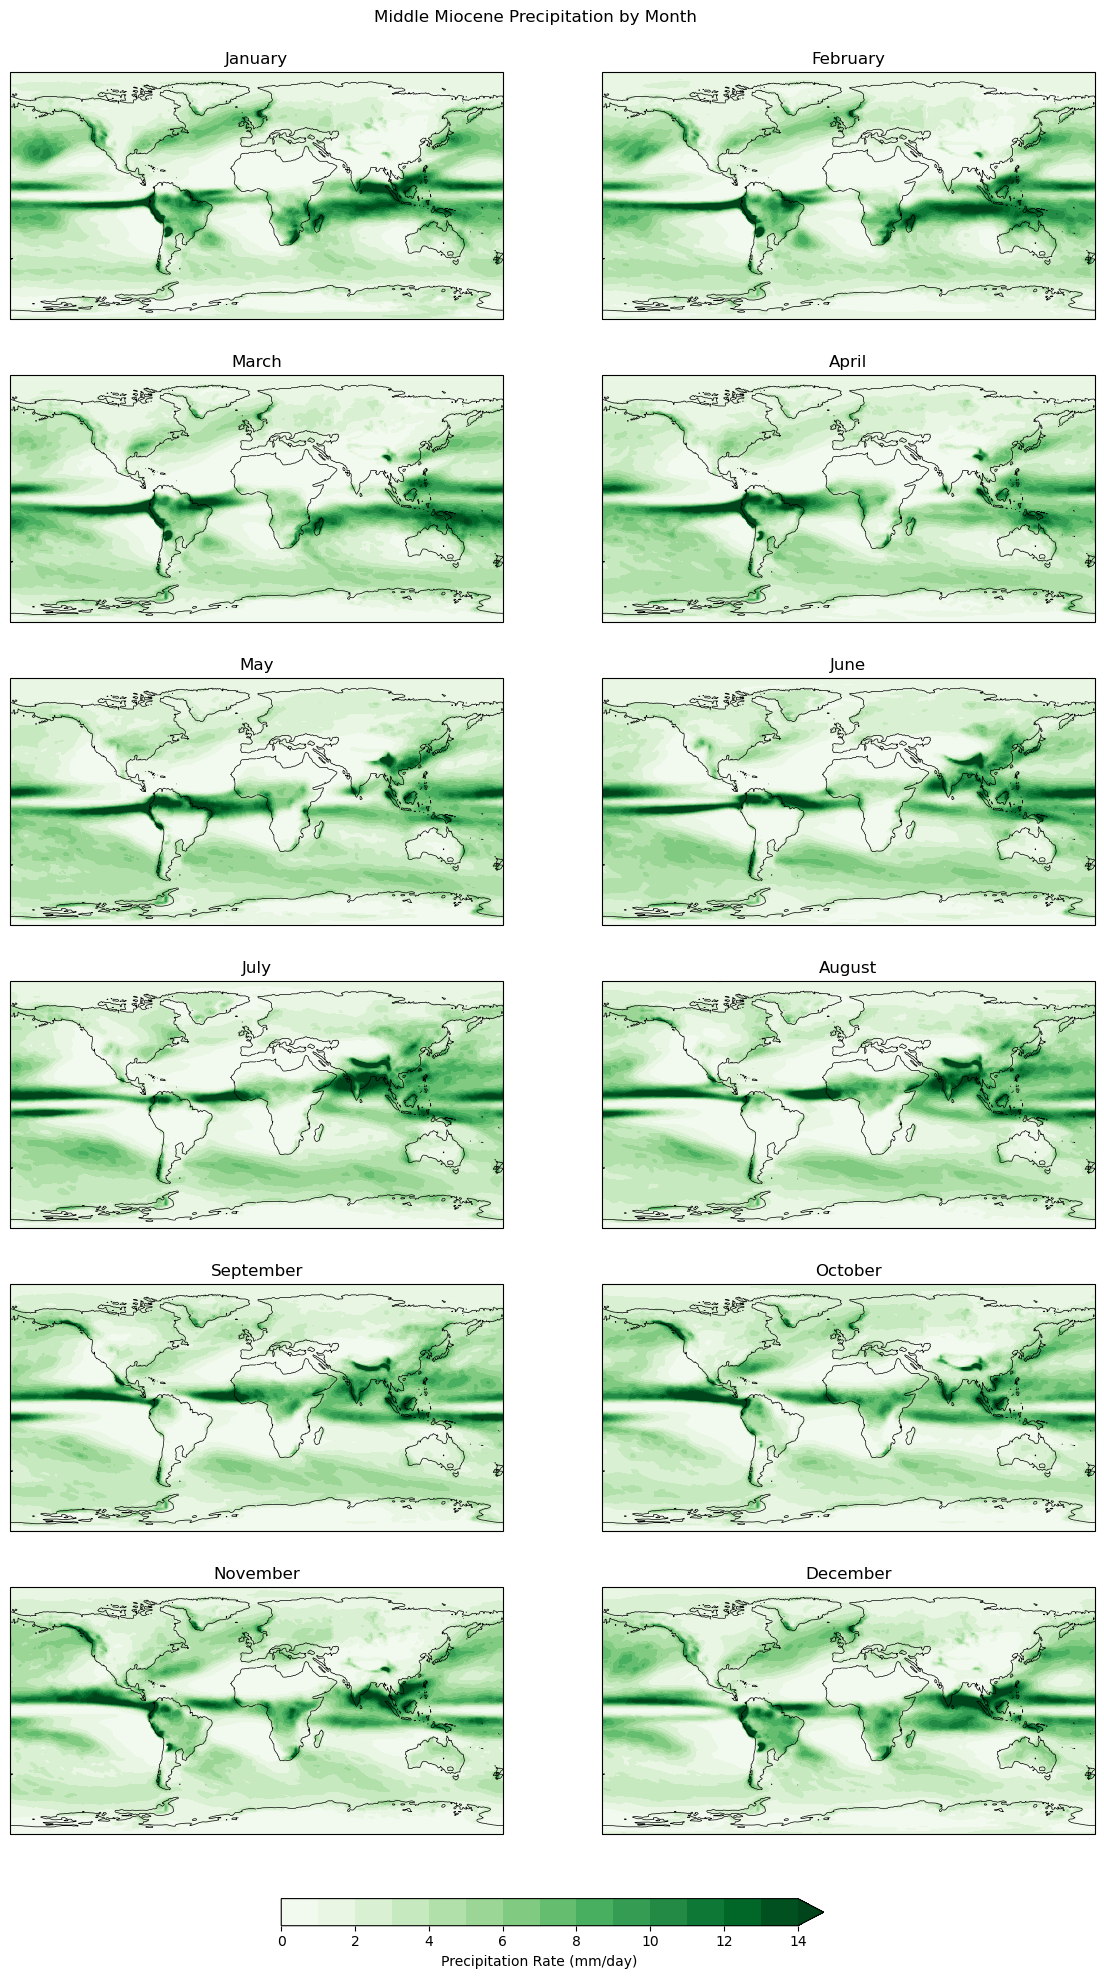

In [5]:
fig, axs = plt.subplots(nrows=6,ncols=2,subplot_kw={"projection":ccrs.PlateCarree()}, figsize=(14,28))
axs = axs.flatten()

month_names = ["January","February","March","April","May","June","July","August","September","October","November","December"]
clevs = np.linspace(0,14,15)

precip_cyclic = []
for i in range(12):   
    lat = precip_avgs[i].lat
    precip_cyclic.append([])
    precip_cyclic[i], lons = add_cyclic_point(precip_avgs[i], coord=precip_avgs[i].lon)
    
    plot = axs[i].contourf(lons,lat,precip_cyclic[i],levels=clevs,transform=ccrs.PlateCarree(),cmap="Greens",extend="max")

    axs[i].contour(topo_file.lon, topo_file.lat, topo_file.topo, levels=[0], transform=ccrs.PlateCarree(), colors="k", linewidths=0.5)

    axs[i].set_title(month_names[i])

fig.colorbar(plot, ax=axs, orientation="horizontal", shrink=0.5, pad=0.03, label="Precipitation Rate (mm/day)")
plt.suptitle("Middle Miocene Precipitation by Month", y=0.9)